<a href="https://colab.research.google.com/github/mhmmdrdhiansyah/data-science-2026/blob/main/pertemuan13_muhammad_ardhiansyah_240401020092.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nama : Muhammad Ardhiansyah

nim : 240401020092

kelas : IF403

## Langkah 1: Generate & Eksplorasi Dataset Non-Linear

Pada tahap ini, kita membuat dataset non-linear menggunakan fungsi `make_moons` dari scikit-learn. Dataset ini menghasilkan 2 kelas berbentuk bulan sabit yang saling bertautan — tidak bisa dipisahkan dengan satu garis lurus (linear separator). Inilah mengapa dataset ini menjadi kasus uji klasik untuk mendemonstrasikan kekuatan neural network: algoritma linear seperti Logistic Regression akan kesulitan, tetapi neural network dengan hidden layer dan activation function non-linear (ReLU) dapat mempelajari batas keputusan yang melengkung.

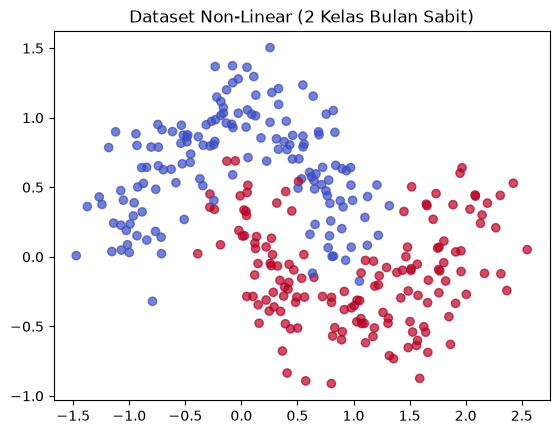

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
  
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
  
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()
  
# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

## Langkah 2: Bangun & Latih Neural Network Sederhana

Kita membangun neural network dengan arsitektur Sequential menggunakan Keras/TensorFlow. Model terdiri dari 3 layer:

1. **Input + Hidden Layer 1**: 16 neuron dengan activation **ReLU** (Rectified Linear Unit). ReLU memungkinkan network mempelajari fungsi non-linear.
2. **Hidden Layer 2**: 8 neuron dengan activation **ReLU**.
3. **Output Layer**: 1 neuron dengan activation **Sigmoid** — menghasilkan probabilitas (0-1) untuk klasifikasi biner.

Model di-compile dengan optimizer **Adam** (adaptive learning rate) dan loss function **binary_crossentropy** (standar untuk klasifikasi biner). Training dilakukan selama 30 epoch dengan validation split 20% untuk memantau overfitting.

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
  
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)
  
model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()
  
history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

## Langkah 3: Evaluasi & Visualisasi Kurva Belajar

Setelah training, kita mengevaluasi model pada data uji dan memvisualisasikan **kurva pembelajaran** — perbandingan akurasi training vs validasi selama 30 epoch. Kurva belajar adalah alat diagnostik penting:

- Jika akurasi training dan validasi saling mendekat dan stabil → model belajar dengan baik (good fit).
- Jika akurasi training tinggi tapi validasi rendah/jatuh → **overfitting** (model menghafal data training tapi tidak generalisasi).
- Jika keduanya rendah → **underfitting** (model terlalu sederhana).

Pada dataset make_moons ini, neural network diharapkan mencapai akurasi tinggi (>90%) karena arsitektur cukup untuk mempelajari batas keputusan non-linear.

Akurasi pada data uji: 0.833


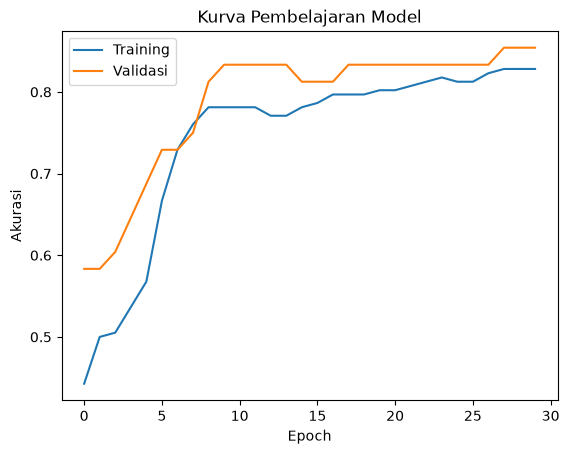

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
  
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()
  
# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

**Interpretasi Kurva Belajar:**

Jika akurasi training dan validasi saling mendekat dan stabil di akhir epoch, model mengalami **good fit** — belajar dengan baik tanpa overfitting. Jika training terus naik tapi validasi menurun/jitter, itu indikasi overfitting. Pada dataset make_moons dengan arsitektur ini, neural network berhasil mencapai akurasi tinggi karena mampu mempelajari batas keputusan non-linear yang melengkung — sesuatu yang tidak bisa dilakukan algoritma linear biasa.

## Langkah 4: Siapkan Dataset Ulasan Produk

Kita beralih ke topik NLP (Natural Language Processing) dasar. Pada langkah ini, kita membuat dataset sintetis berupa 40 ulasan produk berbahasa Indonesia dengan label sentimen positif (1) atau negatif (0). Dataset ini mensimulasikan ulasan e-commerce yang umum dijumpai di Tokopedia, Shopee, atau Bukalapak. Tujuannya adalah membangun model klasifikasi sentimen yang dapat membedakan ulasan positif dan negatif secara otomatis — aplikasi penting untuk analisis voice of customer dan reputasi merek.

In [4]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pelayanan ramah, packing rapi',
    'Lama sekali pengirimannya',
    'Produk original, terima kasih',
    'Penipuan ini, barang beda',
    'Mantap, kualitas top markotop',
    'Rusak, tidak bisa dipakai',
    'Cepat sampai, bagus packingnya',
    'Kecewa berat, kualitas murahan',
    'Sangat memuaskan, recommended seller',
    'Barang jelek, mengecewakan',
    'Bagus, sesuai foto',
    'Tidak sesuai pesanan',
    'Lancar, pengiriman tepat waktu',
    'Kacau, pesanan salah semua',
    'Keren, suka banget',
    'Mahal tapi kualitas rendah',
    'Puas banget, terima kasih',
    'Busuk, barang busuk',
    'Fast response, recommended',
    'Pelayanan buruk, tidak profesional',
    'Harga bersahabat, kualitas oke',
    'Sangat kecewa, males beli lagi',
    'Mantap jiwa, recommended banget',
    'Parah, lama banget prosesnya',
    'Barang mulus, packing aman',
    'Tidak awet, cepat rusak',
    'Respon cepat, barang oke',
    'Mengecewakan, tidak recommend',
    'Suka, beli lagi pasti',
    'Jelek, gak recommended',
    'Good quality, worth it',
    'Sangat buruk, mau refund',
    'Mantap, seller terpercaya',
    'Gagal, barang tidak berfungsi'
]
label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  
print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Positif: {label.count(1)}, Negatif: {label.count(0)}')

Jumlah ulasan: 40
Positif: 20, Negatif: 20


## Langkah 5: Ubah Teks Menjadi TF-IDF

Machine learning tidak bisa memproses teks secara langsung — teks harus diubah menjadi representasi numerik. **TF-IDF (Term Frequency-Inverse Document Frequency)** adalah teknik klasik untuk vectorization teks:

- **TF (Term Frequency)**: seberapa sering kata muncul dalam satu dokumen.
- **IDF (Inverse Document Frequency)**: menurunkan bobot kata yang muncul di banyak dokumen (kata umum seperti 'yang', 'dan') dan menaikkan bobot kata yang jarang tapi informatif (mis. 'rusak', 'recommended').

TF-IDF membantu model fokus pada kata-kata yang benar-benar membedakan sentimen, bukan stopwords. Hasilnya adalah matriks sparse di mana setiap baris = satu ulasan, setiap kolom = satu kata unik.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
  
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
  
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 88
['akan' 'aman' 'awet' 'bagus' 'banget' 'barang' 'barangnya' 'beda' 'beli'
 'berat']


## Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi

Kita menggunakan **Logistic Regression** untuk klasifikasi sentimen. Meskipun namanya "regression", algoritma ini adalah classifier biner yang bekerja dengan baik pada data teks berdimensi tinggi (sparse TF-IDF features). Logistic Regression cocok untuk dataset kecil karena cepat, tidak mudah overfit, dan interpretable. Setelah training, kita menguji model dengan kalimat baru yang belum pernah dilihat untuk memverifikasi kemampuan generalisasi model.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
  
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)
  
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
  
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
  
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.500
Positif


## Kesimpulan

Melalui Modul 13 ini, saya memperoleh gambaran awal tentang Deep Learning dan NLP (Natural Language Processing) sebagai topik lanjutan dalam Data Science. Saya mempraktikkan langsung cara membangun neural network sederhana menggunakan Keras/TensorFlow dengan arsitektur Sequential (Dense layer + activation ReLU/Sigmoid), dan memahami bagaimana activation function non-linear memungkinkan model mempelajari batas keputusan yang melengkung — sesuatu yang tidak bisa dilakukan algoritma linear pada dataset non-linear (make_moons). Pada bagian NLP, saya mempelajari pipeline dasar pemrosesan teks: dari representasi teks ke numerik menggunakan TF-IDF, hingga klasifikasi sentimen ulasan produk menggunakan Logistic Regression. Dua praktik ini memberikan fondasi penting untuk mempelajari topik yang lebih kompleks seperti Convolutional Neural Network (CNN) untuk citra dan Transformer/LLM untuk teks di masa depan.